In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_excel("online_course_recommendation_v2.xlsx")

# Display first 5 rows
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [3]:
# Shape of dataset
print(df.shape)

(100000, 14)


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

#### 1. Checking dimensions, datatypes and statistical summary

In [5]:
# Statistical summary
df.describe()

,user_id,course_id,course_duration_hours,rating,enrollment_numbers,course_price,feedback_score,time_spent_hours,previous_courses_taken
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,24935.663570,5006.863560,52.38354,3.959859,25052.822850,261.073369,0.746865,20.691054,4.992670
std,14406.960108,2882.085456,27.42347,0.729958,14388.188356,139.013758,0.143683,13.669148,2.237259
min,1.000000,1.000000,5.00000,1.000000,50.000000,20.000000,0.092000,1.000000,0.000000
25%,12487.750000,2523.000000,28.60000,3.500000,12583.750000,140.100000,0.649000,9.900000,3.000000
50%,24793.500000,5012.000000,52.40000,4.000000,25057.500000,262.310000,0.750000,19.920000,5.000000
75%,37382.250000,7502.000000,76.10000,4.500000,37522.000000,381.702500,0.851000,30.080000,6.000000
max,49999.000000,9999.000000,100.00000,5.000000,49999.000000,500.000000,1.000000,84.150000,19.000000


#### 2. Checking for null values

In [6]:
# Missing value count
df.isnull().sum()

user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64

#### 3. No missing values found

#### Checking duplicate observations

In [7]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

#### No duplicate records found

#### 4. Understanding cardinality of variables

In [8]:
# Unique values in each column
df.nunique()

user_id                     43242
course_id                    9998
course_name                    20
instructor                     20
course_duration_hours         951
certification_offered           2
difficulty_level                3
rating                         41
enrollment_numbers          43085
course_price                41999
feedback_score                780
study_material_available        2
time_spent_hours             5978
previous_courses_taken         19
dtype: int64

#### 5. Understanding category distribution

In [9]:
df['difficulty_level'].value_counts()

df['certification_offered'].value_counts()

df['study_material_available'].value_counts()

study_material_available
Yes    85147
No     14853
Name: count, dtype: int64

#### 6. Outlier Analysis

In [10]:
num_cols = [
    'course_duration_hours',
    'rating',
    'enrollment_numbers',
    'course_price',
    'feedback_score',
    'time_spent_hours',
    'previous_courses_taken'
]

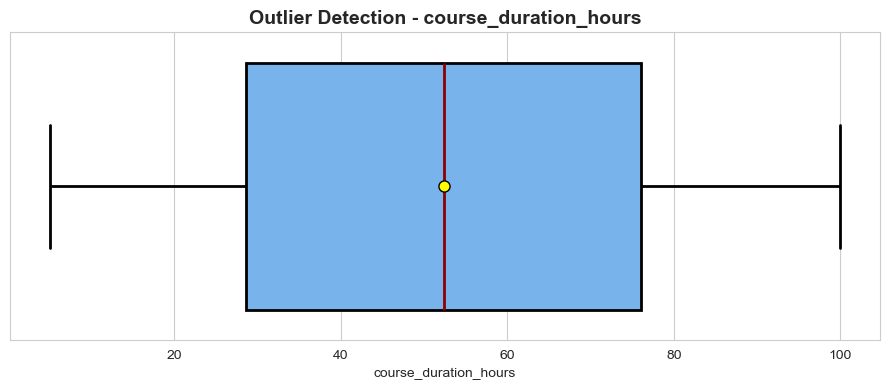

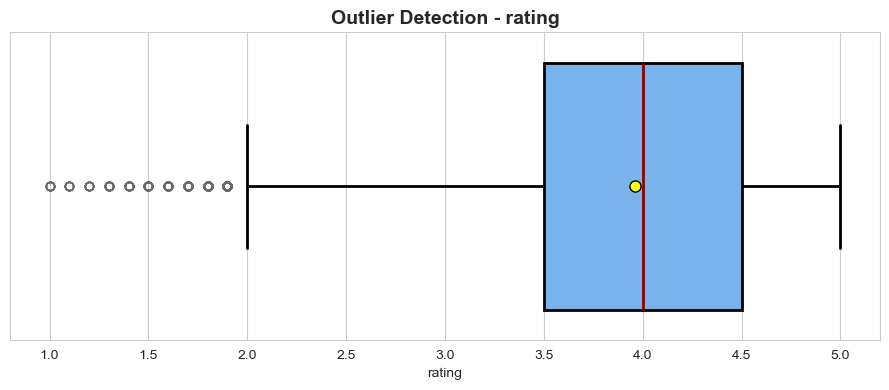

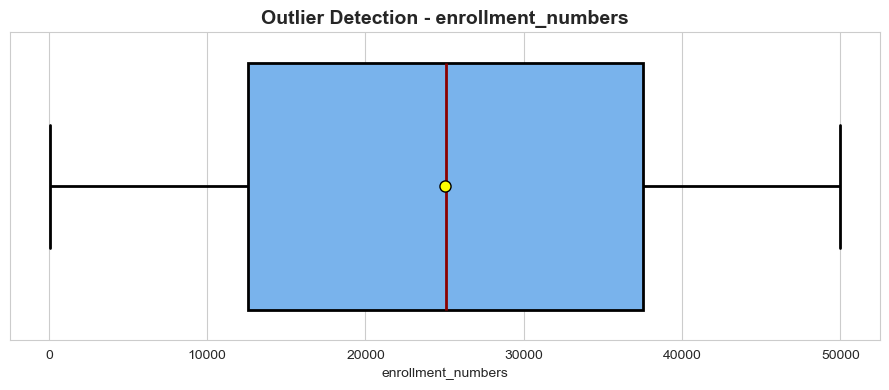

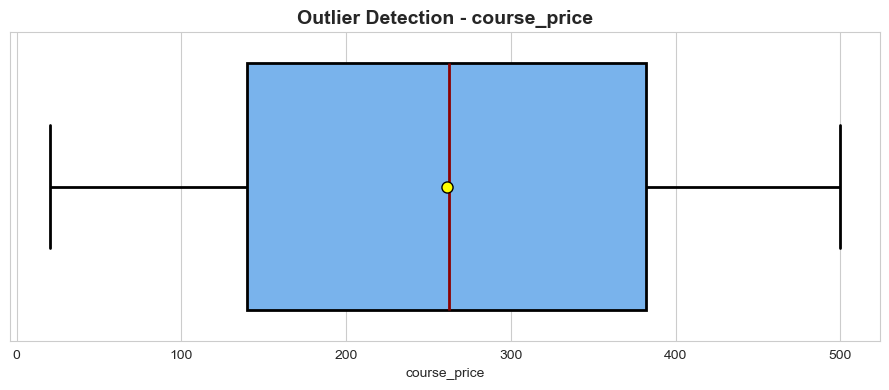

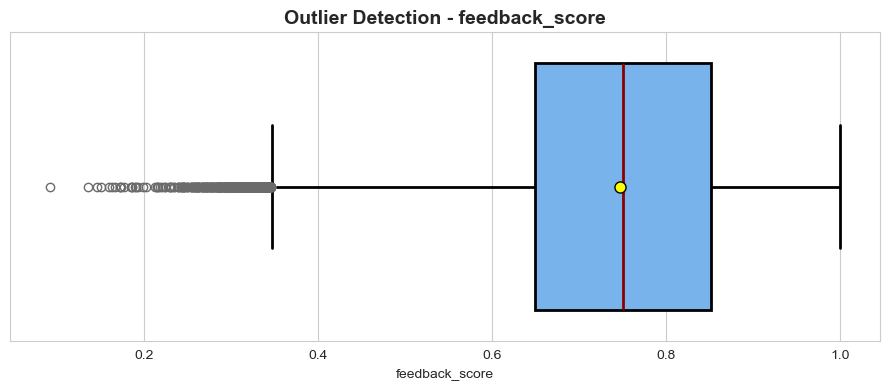

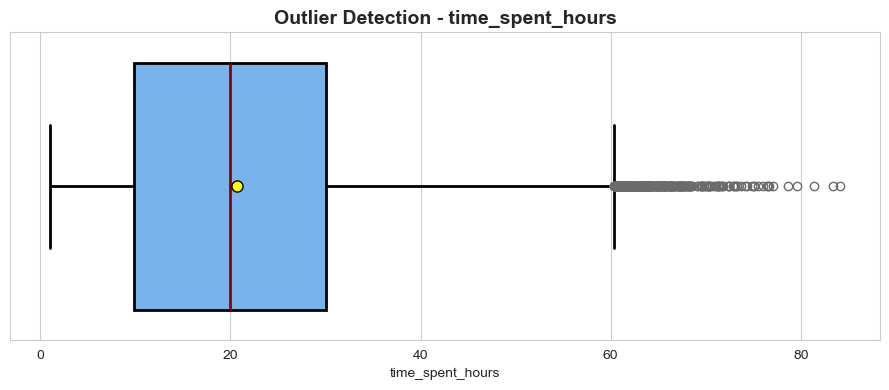

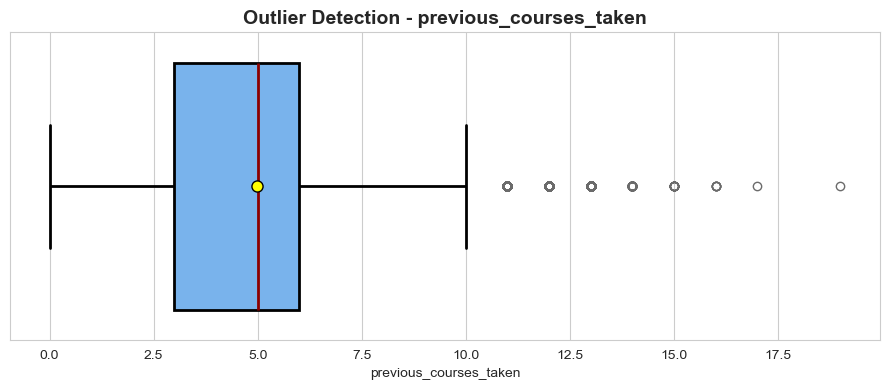

In [11]:
sns.set_style("whitegrid")

for col in num_cols:

    plt.figure(figsize=(9,4))

    sns.boxplot(
        x=df[col],
        color='#66b3ff',
        linewidth=2,
        showmeans=True,
        meanprops={
            'marker':'o',
            'markerfacecolor':'yellow',
            'markeredgecolor':'black',
            'markersize':8
        },
        boxprops=dict(edgecolor='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        medianprops=dict(color='darkred', linewidth=2)
    )

    plt.title(
        f'Outlier Detection - {col}',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

#### Detecting potential outliers in numerical features
- Outliers observed but retained as they may contain valuable recommendation information.

### EDA 1: Course Distribution

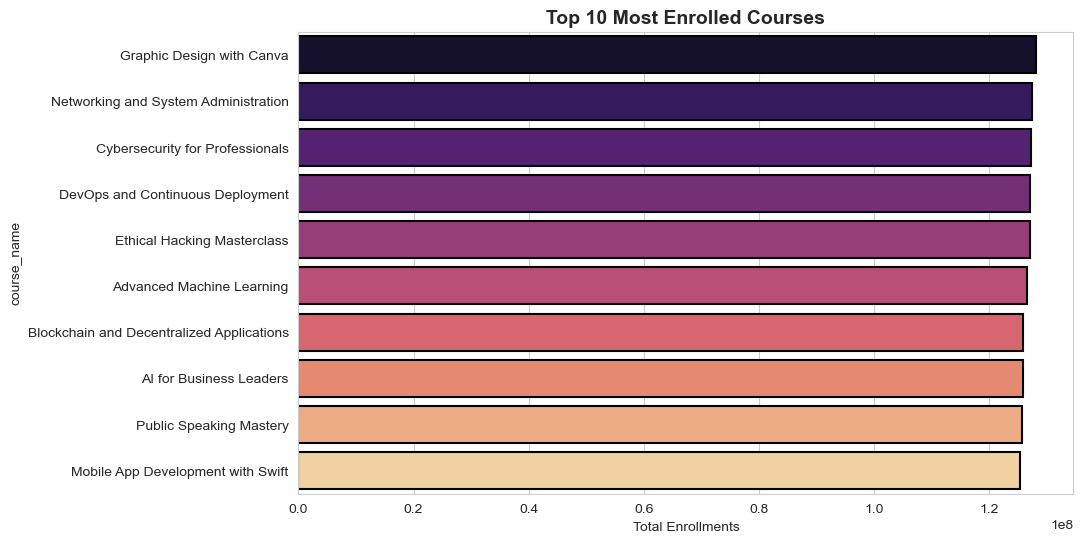

In [12]:
top_courses = (
    df.groupby('course_name')['enrollment_numbers']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_courses.values,
    y=top_courses.index,
    palette='magma',
    edgecolor='black',
    linewidth=1.5
)

plt.title('Top 10 Most Enrolled Courses',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Total Enrollments')

plt.show()

#### Insight:
- The enrollment numbers are distributed almost equally among the top 10 courses, with Graphic Design with Canva having the highest enrollments.
- Technical courses such as Cybersecurity, DevOps, Networking, and Machine Learning also show consistently high demand.
- This indicates that learners are interested in both technical and professional skill development, suggesting a balanced demand across different learning domains.

### EDA 2: Difficulty Level Distribution

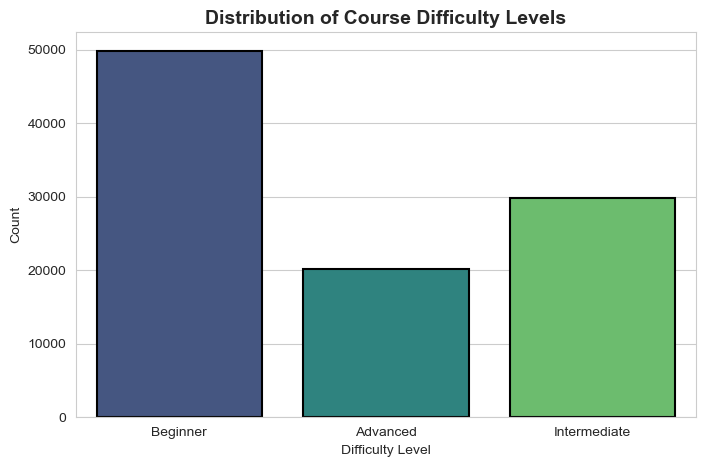

In [13]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='difficulty_level',
    data=df,
    palette='viridis',
    edgecolor='black',
    linewidth=1.5
)

plt.title('Distribution of Course Difficulty Levels',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Difficulty Level')
plt.ylabel('Count')

plt.show()

#### Insight:
- Beginner-level courses make up the largest portion of the dataset, followed by Intermediate and Advanced courses.
-  This suggests that the platform mainly targets new learners who are starting their learning journey.
- Offering more beginner courses can help attract a wider audience before recommending intermediate and advanced courses.

### EDA 3: Certification Offered

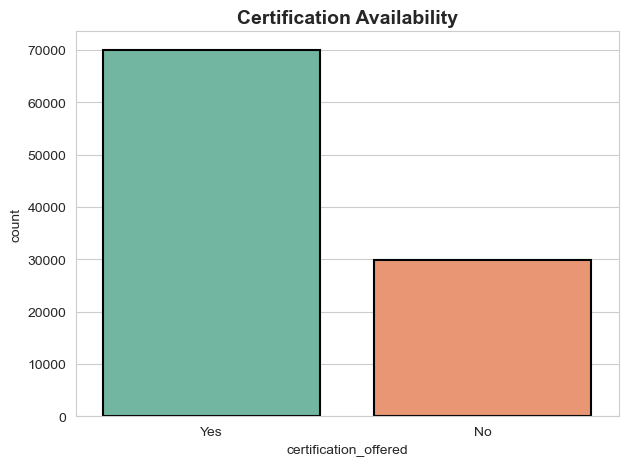

In [14]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='certification_offered',
    data=df,
    palette='Set2',
    edgecolor='black',
    linewidth=1.5
)

plt.title('Certification Availability',
          fontsize=14,
          fontweight='bold')

plt.show()

#### Insight:
- A significantly higher number of courses offer certifications compared to those without certifications.
- This indicates that certification is an important feature of the platform and may increase the attractiveness of courses.
- Certification can be considered a valuable factor while recommending courses to learners.

### EDA-4: Rating Distribution

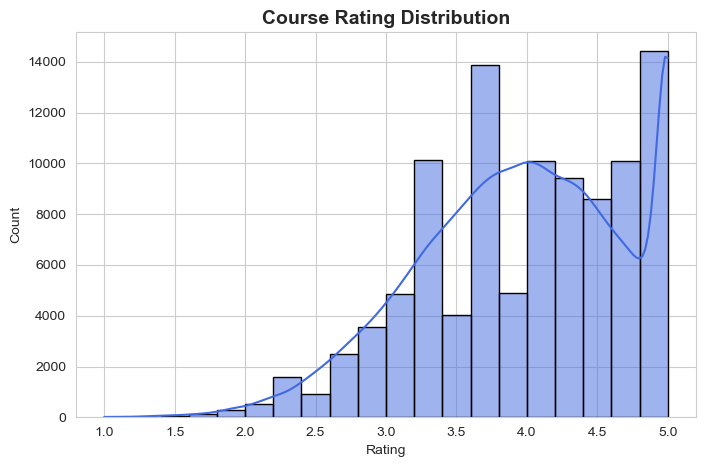

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['rating'],
    bins=20,
    color='royalblue',
    edgecolor='black',
    kde=True
)

plt.title('Course Rating Distribution',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Rating')

plt.show()

#### Insight:
- Most course ratings fall between 3.5 and 5.0, with a noticeable concentration around 4.0–5.0.
- Very few courses receive low ratings below 2.5.
- This indicates that the overall learner satisfaction is high and most courses are well received by users.

### EDA-5: Course Price Distribution

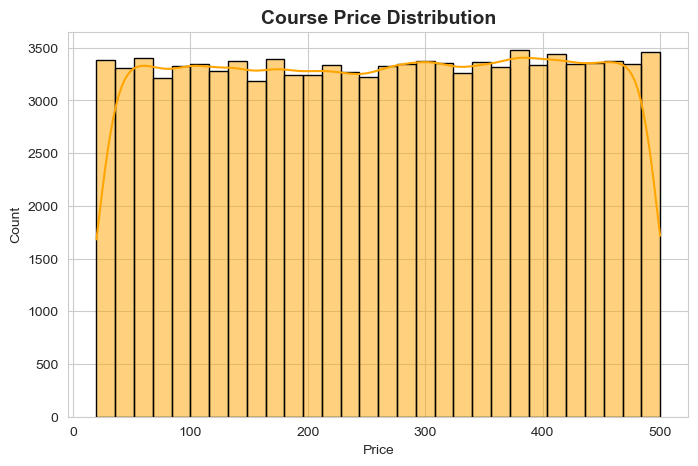

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['course_price'],
    bins=30,
    color='orange',
    edgecolor='black',
    kde=True
)

plt.title('Course Price Distribution',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Price')

plt.show()

#### Insight:
- Course prices are spread fairly evenly across the available price range, with no major concentration at a particular price point.
- This indicates that the platform provides courses across different price segments, giving learners multiple budget options.
- Since prices are uniformly distributed, price alone may not strongly influence course popularity.

### EDA-6: Correlation Heatmap

In [17]:
corr_cols = [
    'course_duration_hours',
    'rating',
    'enrollment_numbers',
    'course_price',
    'feedback_score',
    'time_spent_hours',
    'previous_courses_taken'
]

<Axes: >

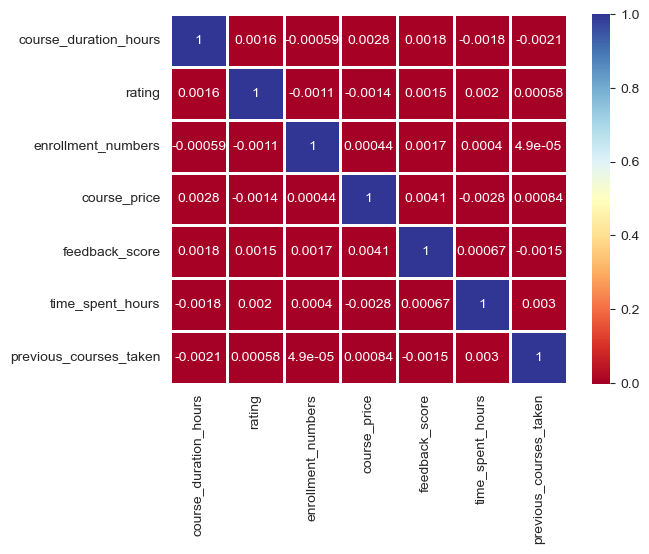

In [18]:
sns.heatmap(df[corr_cols].corr(),
            annot=True,
            cmap='RdYlBu',
            linewidths=1)

#### Insight:
- Course prices are spread fairly evenly across the available price range, with no major concentration at a particular price point.
- This indicates that the platform provides courses across different price segments, giving learners multiple budget options.
- Since prices are uniformly distributed, price alone may not strongly influence course popularity.

### EDA-7: Rating vs Feedback Score

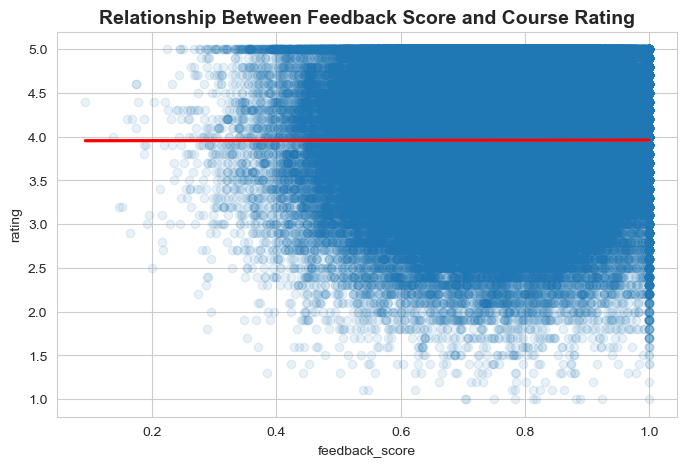

In [19]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='feedback_score',
    y='rating',
    data=df,
    scatter_kws={'alpha':0.1},
    line_kws={'color':'red'}
)

plt.title(
    'Relationship Between Feedback Score and Course Rating',
    fontsize=14,
    fontweight='bold'
)
plt.show()

#### Insight:
- The scatter plot shows no strong linear relationship between feedback score and course rating because the regression line is nearly horizontal.
- Although most ratings are above 3.5, similar feedback scores correspond to a wide range of ratings.
- This suggests that feedback score alone is not a strong predictor of course rating, and additional factors may influence learner ratings.

### Key Findings
- The dataset contains 100,000 learner-course interactions.
- No missing values or duplicate records were found.
- Beginner-level courses dominate the dataset.
- A majority of courses offer certifications.
- Course ratings are generally high, concentrated between 3.5 and 5.
- Course prices are distributed across the entire pricing range.
- No strong linear relationships exist among numerical variables.
- The dataset is suitable for building a recommendation system.

### 7. Feature Engineering
#### 1. Convert Yes/No Columns

In [20]:
# Convert Yes/No into 1/0

df['certification_offered'] = df['certification_offered'].map({
    'Yes':1,
    'No':0
})

df['study_material_available'] = df['study_material_available'].map({
    'Yes':1,
    'No':0
})


 Converting binary categorical features into numerical format

#### 2. Encode Difficulty Level

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['difficulty_level_encoded'] = le.fit_transform(
    df['difficulty_level']
)

In [22]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Advanced': np.int64(0), 'Beginner': np.int64(1), 'Intermediate': np.int64(2)}


 Encoding difficulty levels for machine learning

#### 3. Create Engagement Score

In [23]:
df['engagement_score'] = (
    df['time_spent_hours'] /
    df['course_duration_hours']
)

Higher engagement score indicates students spent more time relative to the course duration.

#### 4. Create Popularity Score

In [24]:
df['popularity_score'] = (
    df['rating'] *
    df['feedback_score'] *
    np.log1p(df['enrollment_numbers'])
)

Combines rating, feedback score and enrollments to estimate overall course popularity.

#### 5. Check New Features

In [25]:
df[['engagement_score',
    'popularity_score']].head()

,engagement_score,popularity_score
0,0.450128,39.772272
1,0.798072,31.920766
2,3.913433,26.401828
3,0.382333,32.394262
4,0.714610,16.239868


#### 6. Prepare Course Feature Dataset

In [26]:
course_features = df[[
    'course_name',
    'instructor',
    'difficulty_level',
    'course_duration_hours',
    'course_price',
    'certification_offered',
    'study_material_available',
    'engagement_score',
    'popularity_score'
]]

In [27]:
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken,difficulty_level_encoded,engagement_score,popularity_score
0,15796,9366,Python for Beginners,Emma Harris,39.1,1,Beginner,5.0,21600,317.50,0.797,1,17.60,4,1,0.450128,39.772272
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,1,Beginner,4.3,15379,40.99,0.770,1,28.97,9,1,0.798072,31.920766
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,1,Beginner,3.9,6431,380.81,0.772,1,52.44,4,1,3.913433,26.401828
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,1,Beginner,3.1,48245,342.80,0.969,0,22.29,6,1,0.382333,32.394262
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,1,Beginner,2.8,34556,381.01,0.555,1,22.01,5,1,0.714610,16.239868


### 8. Content-Based Recommendation System
#### 1. Course Content

In [28]:
# Creating course content information

df['course_content'] = (
    df['course_name'].astype(str) + ' ' +
    df['instructor'].astype(str) + ' ' +
    df['difficulty_level'].astype(str)
)

In [29]:
df[['course_name','course_content']].head()

,course_name,course_content
0,Python for Beginners,Python for Beginners Emma Harris Beginner
1,Cybersecurity for Professionals,Cybersecurity for Professionals Alexander Youn...
2,DevOps and Continuous Deployment,DevOps and Continuous Deployment Dr. Mia Walke...
3,Project Management Fundamentals,Project Management Fundamentals Benjamin Lewis...
4,Ethical Hacking Masterclass,Ethical Hacking Masterclass Daniel White Beginner


#### 2. Duplicate Courses

In [30]:
course_df = df[['course_name','course_content']].drop_duplicates(subset='course_name')
course_df = course_df.reset_index(drop=True)

In [31]:
print(df.shape)
print(course_df.shape)

(100000, 18)
(20, 2)


#### 3. Import TF-IDF

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

#### 4. Text to Numerical Features

In [33]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(course_df['course_content'])

print(tfidf_matrix.shape)

(20, 79)


#### 5. Calculate Similarity

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

 Compute cosine similarity between courses based on TF-IDF features.

#### 6. Index Mapping

In [35]:
course_indices = pd.Series(
    course_df.index,
    index=course_df['course_name']
)

course_indices = course_indices[~course_indices.index.duplicated(keep='first')]

 Create course index mapping for quick course lookup during recommendation.

In [36]:
print(course_df.shape)
print(cosine_sim.shape)

(20, 2)
(20, 20)


#### 7. Recommendation Function

In [37]:
def recommend_courses(course_name, top_n=5):

    idx = course_indices[course_name]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    course_indexes = [
        i[0] for i in similarity_scores
    ]

    recommended_courses = course_df.iloc[course_indexes]['course_name']
    return recommended_courses
    

In [38]:
recommend_courses('Python for Beginners')

17     Stock Market and Trading Strategies
1          Cybersecurity for Professionals
5     Networking and System Administration
3          Project Management Fundamentals
4              Ethical Hacking Masterclass
Name: course_name, dtype: object

In [39]:
type(course_indices['Python for Beginners'])

numpy.int64

In [40]:
recommend_courses('Project Management Fundamentals')

6          Personal Finance and Wealth Building
7     Blockchain and Decentralized Applications
10                      Public Speaking Mastery
18            Fundamentals of Digital Marketing
1               Cybersecurity for Professionals
Name: course_name, dtype: object

In [41]:
recommend_courses('Cybersecurity for Professionals')

8                Graphic Design with Canva
19                 AI for Business Leaders
0                     Python for Beginners
5     Networking and System Administration
3          Project Management Fundamentals
Name: course_name, dtype: object

##### ==========================================
### 9. Collaborative Filtering Recommendation System
##### ==========================================

#### 1. User-Course Matrix

In [42]:
# Creating User-Course Rating Matrix

user_course_matrix = df.pivot_table(
    index='user_id',
    columns='course_name',
    values='rating',
    aggfunc='mean'
)

user_course_matrix.head()

course_name,AI for Business Leaders,Advanced Machine Learning,Blockchain and Decentralized Applications,Cloud Computing Essentials,Cybersecurity for Professionals,Data Visualization with Tableau,DevOps and Continuous Deployment,Ethical Hacking Masterclass,Fitness and Nutrition Coaching,Fundamentals of Digital Marketing,Game Development with Unity,Graphic Design with Canva,Mobile App Development with Swift,Networking and System Administration,Personal Finance and Wealth Building,Photography and Video Editing,Project Management Fundamentals,Public Speaking Mastery,Python for Beginners,Stock Market and Trading Strategies
user_id,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.9,NaN,NaN,NaN,NaN
2,NaN,3.3,4.5,NaN,3.6,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.6,NaN
3,NaN,NaN,NaN,4.1,NaN,NaN,NaN,NaN,NaN,3.7,NaN,4.4,NaN,NaN,4.15,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,3.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Each row represents a user and each column represents a course.
- Ratings are used to identify users with similar preferences.

#### 2. Check Matrix Shape

In [43]:
print(user_course_matrix.shape)

(43242, 20)


#### 3. Replace Missing Ratings

In [44]:
user_course_matrix_filled = user_course_matrix.fillna(0)

user_course_matrix_filled.head()

course_name,AI for Business Leaders,Advanced Machine Learning,Blockchain and Decentralized Applications,Cloud Computing Essentials,Cybersecurity for Professionals,Data Visualization with Tableau,DevOps and Continuous Deployment,Ethical Hacking Masterclass,Fitness and Nutrition Coaching,Fundamentals of Digital Marketing,Game Development with Unity,Graphic Design with Canva,Mobile App Development with Swift,Networking and System Administration,Personal Finance and Wealth Building,Photography and Video Editing,Project Management Fundamentals,Public Speaking Mastery,Python for Beginners,Stock Market and Trading Strategies
user_id,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,3.9,0.0,0.0,0.0,0.0
2,0.0,3.3,4.5,0.0,3.6,4.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,4.6,0.0
3,0.0,0.0,0.0,4.1,0.0,0.0,0.0,0.0,0.0,3.7,0.0,4.4,0.0,0.0,4.15,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,3.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.2,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,3.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0


Replace missing ratings with 0 because unrated courses indicate no interaction.

#### 4. Compute User Similarity

In [45]:
from sklearn.metrics.pairwise import cosine_similarity
user_similarity = cosine_similarity(user_course_matrix_filled)

user_similarity.shape

(43242, 43242)

#### 5. Convert to DataFrame

In [46]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_course_matrix_filled.index,
    columns=user_course_matrix_filled.index
)

user_similarity_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,49989,49990,49991,49992,49994,49995,49996,49997,49998,49999
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.584671,0.0,0.000000,0.0,0.000000,0.000000
2,0.0,1.000000,0.000000,0.376205,0.000000,0.000000,0.000000,0.0,0.275953,0.225971,...,0.271776,0.0,0.594857,0.000000,0.000000,0.0,0.389309,0.0,0.328629,0.000000
3,0.0,0.000000,1.000000,0.340764,0.500587,0.545019,0.451749,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.343409,0.271560,0.0,0.000000,0.0,0.000000,0.537215
4,0.0,0.376205,0.340764,1.000000,0.000000,0.300042,0.000000,0.0,0.000000,0.358979,...,0.000000,0.0,0.374432,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.634317
5,0.0,0.000000,0.500587,0.000000,1.000000,0.581134,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.686013,0.000000,0.0,0.000000,0.0,0.000000,0.000000


#### 6. Find Similar Users

In [47]:
user_similarity_df.loc[15796].sort_values(ascending=False).head(10)

user_id
15796    1.000000
436      0.999971
11487    0.999912
25576    0.999912
12821    0.999912
48035    0.999810
27811    0.999756
7742     0.999640
3244     0.999562
30930    0.999315
Name: 15796, dtype: float64

#### 7. Recommendation Function

In [48]:
def recommend_for_user(user_id, top_n=5):

    similar_users = user_similarity_df[user_id].sort_values(
        ascending=False
    )[1:11]

    similar_user_ids = similar_users.index

    recommended_courses = (
        df[df['user_id'].isin(similar_user_ids)]
       .groupby('course_name')['rating']
       .mean()
       .sort_values(ascending=False)
           .head(top_n)
    )

    return recommended_courses

#### 8. Test

In [49]:
recommend_for_user(15796)

course_name
Python for Beginners                4.045455
DevOps and Continuous Deployment    3.040000
Name: rating, dtype: float64

In [50]:
recommend_for_user(44733)

course_name
AI for Business Leaders             4.083333
Public Speaking Mastery             3.766667
Project Management Fundamentals     3.718182
DevOps and Continuous Deployment    3.450000
Name: rating, dtype: float64

In [51]:
recommend_for_user(861)

course_name
Personal Finance and Wealth Building    4.500000
AI for Business Leaders                 4.130000
Cybersecurity for Professionals         3.830000
Public Speaking Mastery                 3.614286
Advanced Machine Learning               3.337500
Name: rating, dtype: float64

In [52]:
recommend_for_user(38159)

course_name
DevOps and Continuous Deployment    3.96
Project Management Fundamentals     3.80
Name: rating, dtype: float64

### 10. Interpretation

#### Collaborative Filtering
- Recommendations are generated based on similar users.
- Users with similar rating behavior are identified using cosine similarity.
- Highly rated courses from similar users are recommended.

## Deployment - Content based 

In [53]:
import pickle

In [2]:
# Save the processed course dataset into a pickle file

In [54]:
pickle.dump(course_df, open("course_df.pkl", "wb"))

#### This saves the processed course data into a file so we don't need to recreate it every time the application runs.

In [55]:
pickle.dump(cosine_sim, open("cosine_sim.pkl", "wb"))

#### Save the cosine similarity matrix for future recommendations

In [56]:
pickle.dump(course_indices, open("course_indices.pkl", "wb"))

#### This saves the mapping between course names and their index positions, making course lookup faster.

In [57]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'cosine_sim.pkl', 'course_df.pkl', 'course_indices.pkl', 'Model.ipynb', 'online_course_recommendation_v2.xlsx']


#### Display all files created in the current project folder

### Pickle:
After building the recommendation model, I saved the important objects as pickle files. These files store the processed data, similarity matrix, and course index mapping. Instead of recalculating everything whenever the application starts, Streamlit simply loads these files, making the application much faster.